In [1]:

# библиотеки
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
import scipy.stats as sts
from itertools import combinations
from statsmodels.formula.api import ols
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [11]:
# load data
%store -r data
pd.set_option('display.float_format', '{:.3f}'.format)
data2 = data

top_genres = ['Romance', 'Comedy', 'Hentai', 'Fantasy', 'Boys Love']
top_themes = ['School', 'Historical', 'Harem', 'Psychological', 'Isekai']
print(top_genres)
print(data['type'].unique())
print(data['status'].unique())


['Romance', 'Comedy', 'Hentai', 'Fantasy', 'Boys Love']
['doujinshi' 'light_novel' 'manga' 'manhua' 'manhwa' 'novel']
['finished']


In [9]:
filter_data_genre = {}
for genre in top_genres:
    data[f'is_{genre}'] = data['genres'].apply(lambda x: 1 if genre in x else 0)
    genre_yes = data[data[f'is_{genre}'] == 1]['score']
    genre_no = data[data[f'is_{genre}'] == 0]['score']
    _, pl = sts.levene(genre_yes, genre_no)
    _,pny = sts.shapiro(genre_yes)
    _,pnn = sts.shapiro(genre_no)
    filter_data_genre[genre] = [round(pl,3),round(pnn,3),round(pny,3)]
    print(f'{genre}:\nТест Левена: {pl:.3f}\np-value(да):{pny:.3f}\np-value(нет):{pnn:.3f}\n')


Romance:
Тест Левена: 0.731
p-value(да):0.194
p-value(нет):0.226

Comedy:
Тест Левена: 0.978
p-value(да):0.199
p-value(нет):0.164

Boys Love:
Тест Левена: 0.471
p-value(да):0.012
p-value(нет):0.498

Drama:
Тест Левена: 0.678
p-value(да):0.998
p-value(нет):0.091

Erotica:
Тест Левена: 0.218
p-value(да):0.021
p-value(нет):0.314



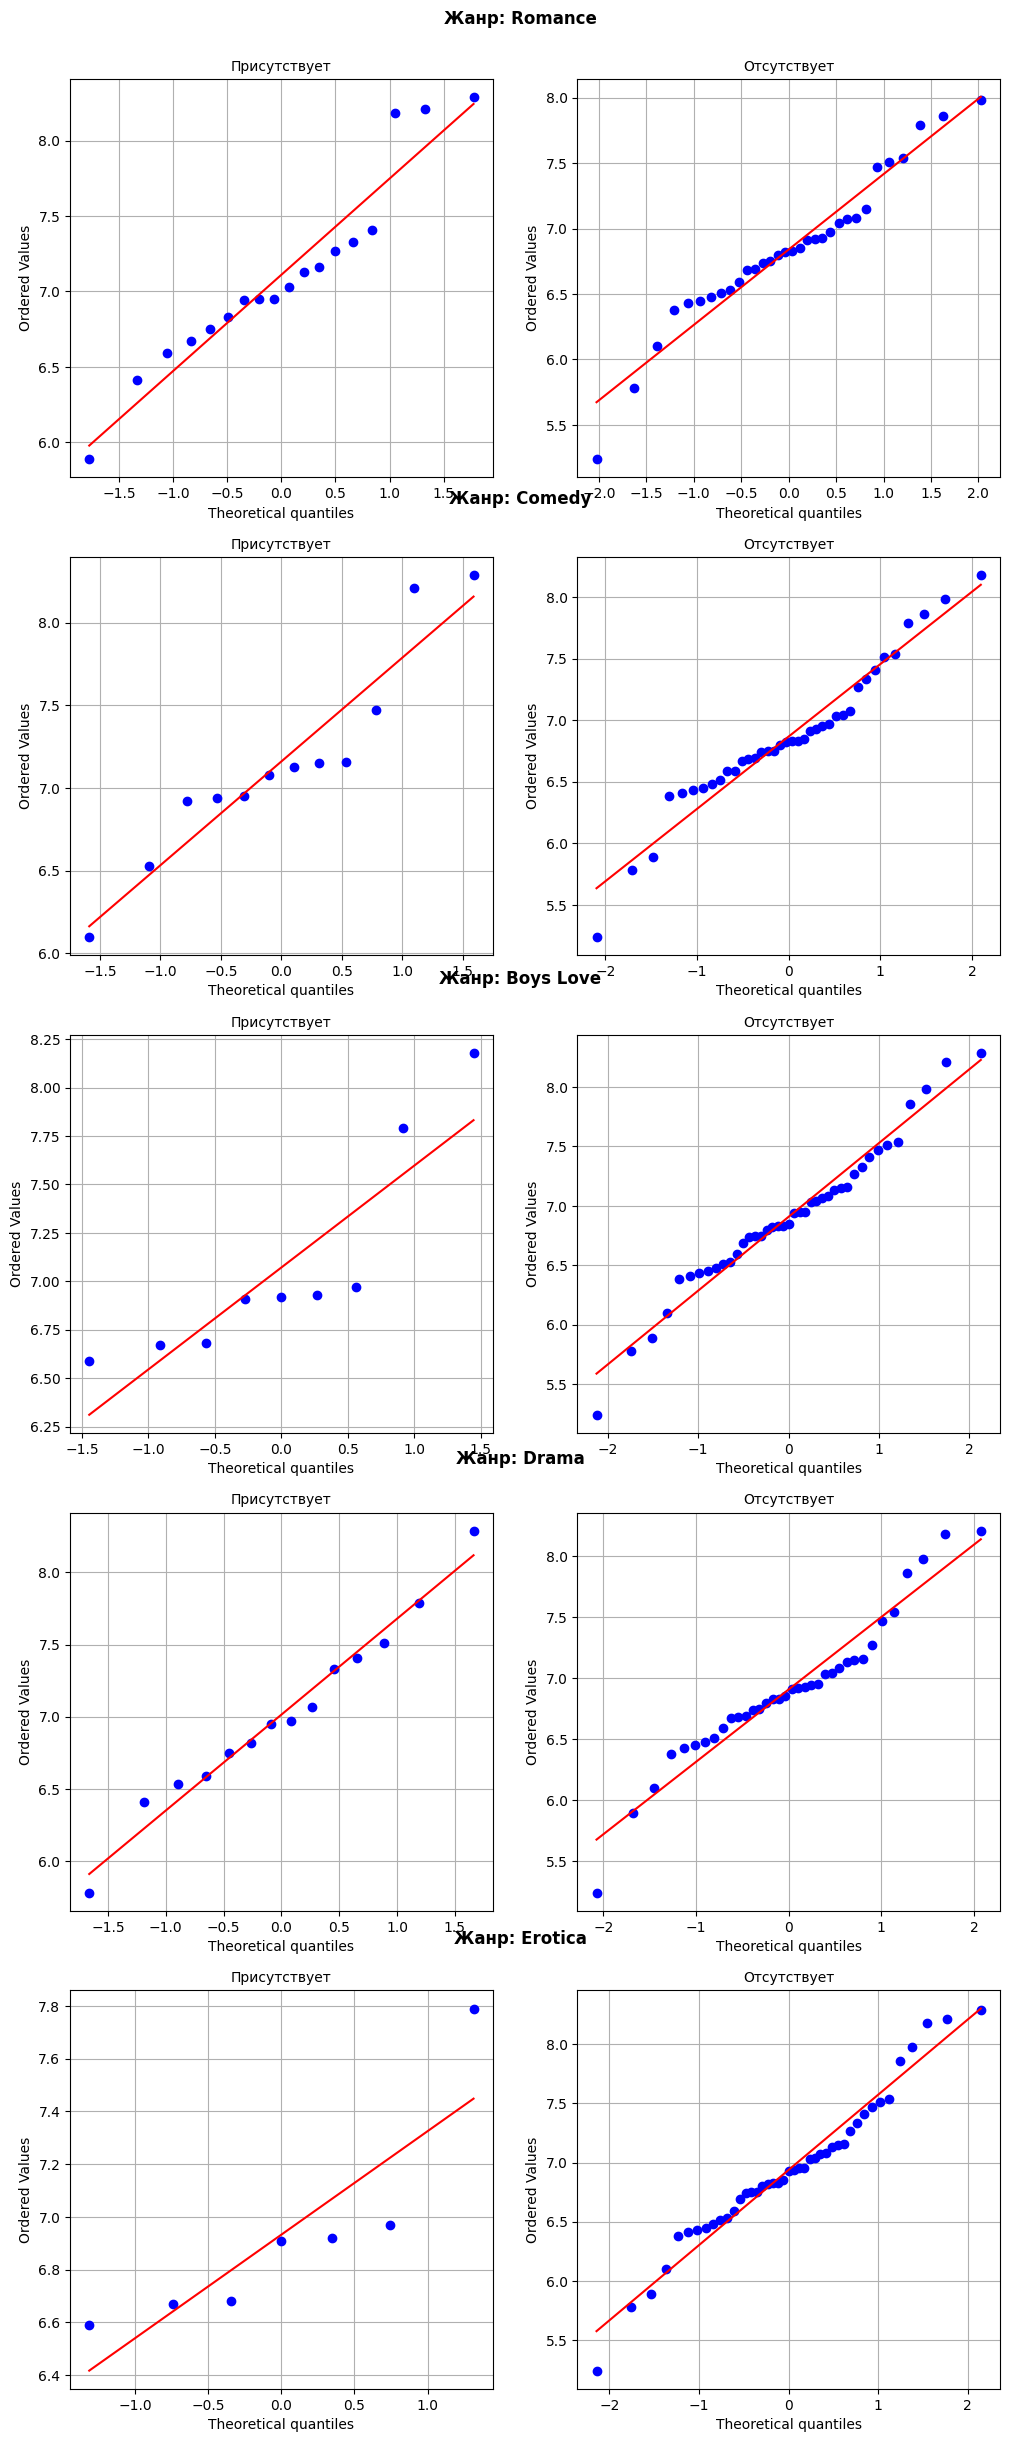

In [10]:
fig, axes = plt.subplots(len(top_genres), 2,figsize=(12, 6*len(top_genres))) 
for i in range(len(top_genres)):
    genre = top_genres[i]

    genre_yes = data[data[f'is_{genre}'] == 1]['score'].dropna()
    genre_no = data[data[f'is_{genre}'] == 0]['score'].dropna()

    sts.probplot(genre_yes, plot=axes[i, 0])  # Используем plot вместо ax
    sts.probplot(genre_no, plot=axes[i, 1])   # И индексацию [i,0] вместо [i][0]
    
    fig.text(
        x=0.5,  # Центрируем по горизонтали
        y=0.9 - i*0.8/len(top_genres),  # Позиционируем по вертикали
        s=f'Жанр: {genre}',
        ha='center',
        va='center',
        fontsize=12,
        fontweight='bold'
    )
    
    # Подписи для подграфиков (опционально)
    axes[i, 0].set_title('Присутствует', fontsize=10)
    axes[i, 1].set_title('Отсутствует', fontsize=10)
    axes[i, 0].grid(True)
    axes[i, 1].grid(True)

In [12]:
mas = []
for genre in top_genres:
    arr = filter_data_genre[genre]
    if arr[0] > 0.005 and arr[1] > 0.05 and arr[2] > 0.05:
        mas.append(genre)
        genre_yes = data[data[f'is_{genre}'] == 1]['score'].dropna()
        genre_no = data[data[f'is_{genre}'] == 0]['score'].dropna()

        f_stat, p_value = sts.f_oneway(genre_yes, genre_no)
        f_critical = sts.f.ppf(0.95, 1, 48)
        
        formula = f'score ~ C(is_{genre})'
        model = ols(formula, data=data).fit()
        anova_table = sm.stats.anova_lm(model, typ=2)
        

        sum_sq_0 = anova_table['sum_sq'][f'C(is_{genre})'] 
        sum_sq_1 = anova_table['sum_sq'][f'Residual']
        R2 = sum_sq_0/(sum_sq_0 + sum_sq_1)
        
        print(f'{genre}:\n F-факт:{f_stat:.3f}\n F-крит:{f_critical:.3f}\n P-value:{p_value:.3f}\n')
        print(f'R^2 = {R2:.3f}',end="\n\n")
        print(anova_table.round(3),end="\n\n")


Romance:
 F-факт:2.423
 F-крит:4.043
 P-value:0.126

R^2 = 0.048

               sum_sq     df     F  PR(>F)
C(is_Romance)   0.845  1.000 2.423   0.126
Residual       16.741 48.000   NaN     NaN

Comedy:
 F-факт:2.257
 F-крит:4.043
 P-value:0.140

R^2 = 0.045

              sum_sq     df     F  PR(>F)
C(is_Comedy)   0.790  1.000 2.257   0.140
Residual      16.796 48.000   NaN     NaN

Drama:
 F-факт:0.317
 F-крит:4.043
 P-value:0.576

R^2 = 0.007

             sum_sq     df     F  PR(>F)
C(is_Drama)   0.116  1.000 0.317   0.576
Residual     17.470 48.000   NaN     NaN



In [ ]:
#сделать дисперсионный анализ с использованием типа манги и оценки!!!


# Создаем пустой DataFrame для результатов
result = pd.DataFrame(index=top_genres, columns=top_themes)

# Создаем столбцы, указывающие, есть ли у произведения топовый жанр или тему
for genre in  top_genres:
  data[f'has {genre}'] = data['genres'].apply(lambda x: 1 if genre in x else 0)
for theme in  top_themes:
  data[f'has {theme}'] = data['themes'].apply(lambda x: 1 if theme in x else 0)


In [63]:
for i in range(len(top_genres) - 1):
  print(f"g{i} = {top_genres[i]}")

tables = []

for i in range(len(top_genres) - 1):
  for j in range(i + 1, len(top_genres) - 1):
    data[f'g{i}_{j}'] = 2 * data[f'has {top_genres[i]}'] + data[f'has {top_genres[j]}']
    model = ols(f'score ~ g{i}_{j} + type + g{i}_{j}:type', data=data).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    tables.append(anova_table)

g0 = Romance
g1 = Comedy
g2 = Boys Love
g3 = Drama
g4 = Erotica


In [ ]:
for i in range(5):
  print(tables[i])

In [66]:
for i in range(5, 10):
  print(tables[i])

           sum_sq     df     F  PR(>F)
type        0.542  2.000 1.021   0.364
g1_3        0.000  1.000 0.000   1.000
g1_3:type   1.735  2.000 3.268   0.042
Residual   25.209 95.000   NaN     NaN
           sum_sq     df     F  PR(>F)
type        0.440  2.000 0.787   0.458
g1_4        0.395  1.000 1.411   0.238
g1_4:type   0.234  2.000 0.418   0.659
Residual   26.315 94.000   NaN     NaN
           sum_sq     df     F  PR(>F)
type        0.542  2.000 0.963   0.385
g2_3        0.000  1.000 0.000   1.000
g2_3:type   0.237  2.000 0.421   0.657
Residual   26.707 95.000   NaN     NaN
           sum_sq     df     F  PR(>F)
type        0.561  2.000 1.011   0.368
g2_4        0.396  1.000 1.428   0.235
g2_4:type   0.461  2.000 0.831   0.439
Residual   26.086 94.000   NaN     NaN
           sum_sq     df     F  PR(>F)
type        0.529  2.000 0.928   0.399
g3_4        0.071  1.000 0.250   0.618
g3_4:type   0.066  2.000 0.117   0.890
Residual   26.806 94.000   NaN     NaN


In [243]:
model = ols(f'score ~ status', data=data).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

model = ols(f'score ~ stattus', data=data).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)


          sum_sq     df     F  PR(>F)
status     0.298  2.000 0.580   0.564
Residual  12.058 47.000   NaN     NaN
          sum_sq     df     F  PR(>F)
type       0.101  2.000 0.194   0.825
Residual  12.255 47.000   NaN     NaN


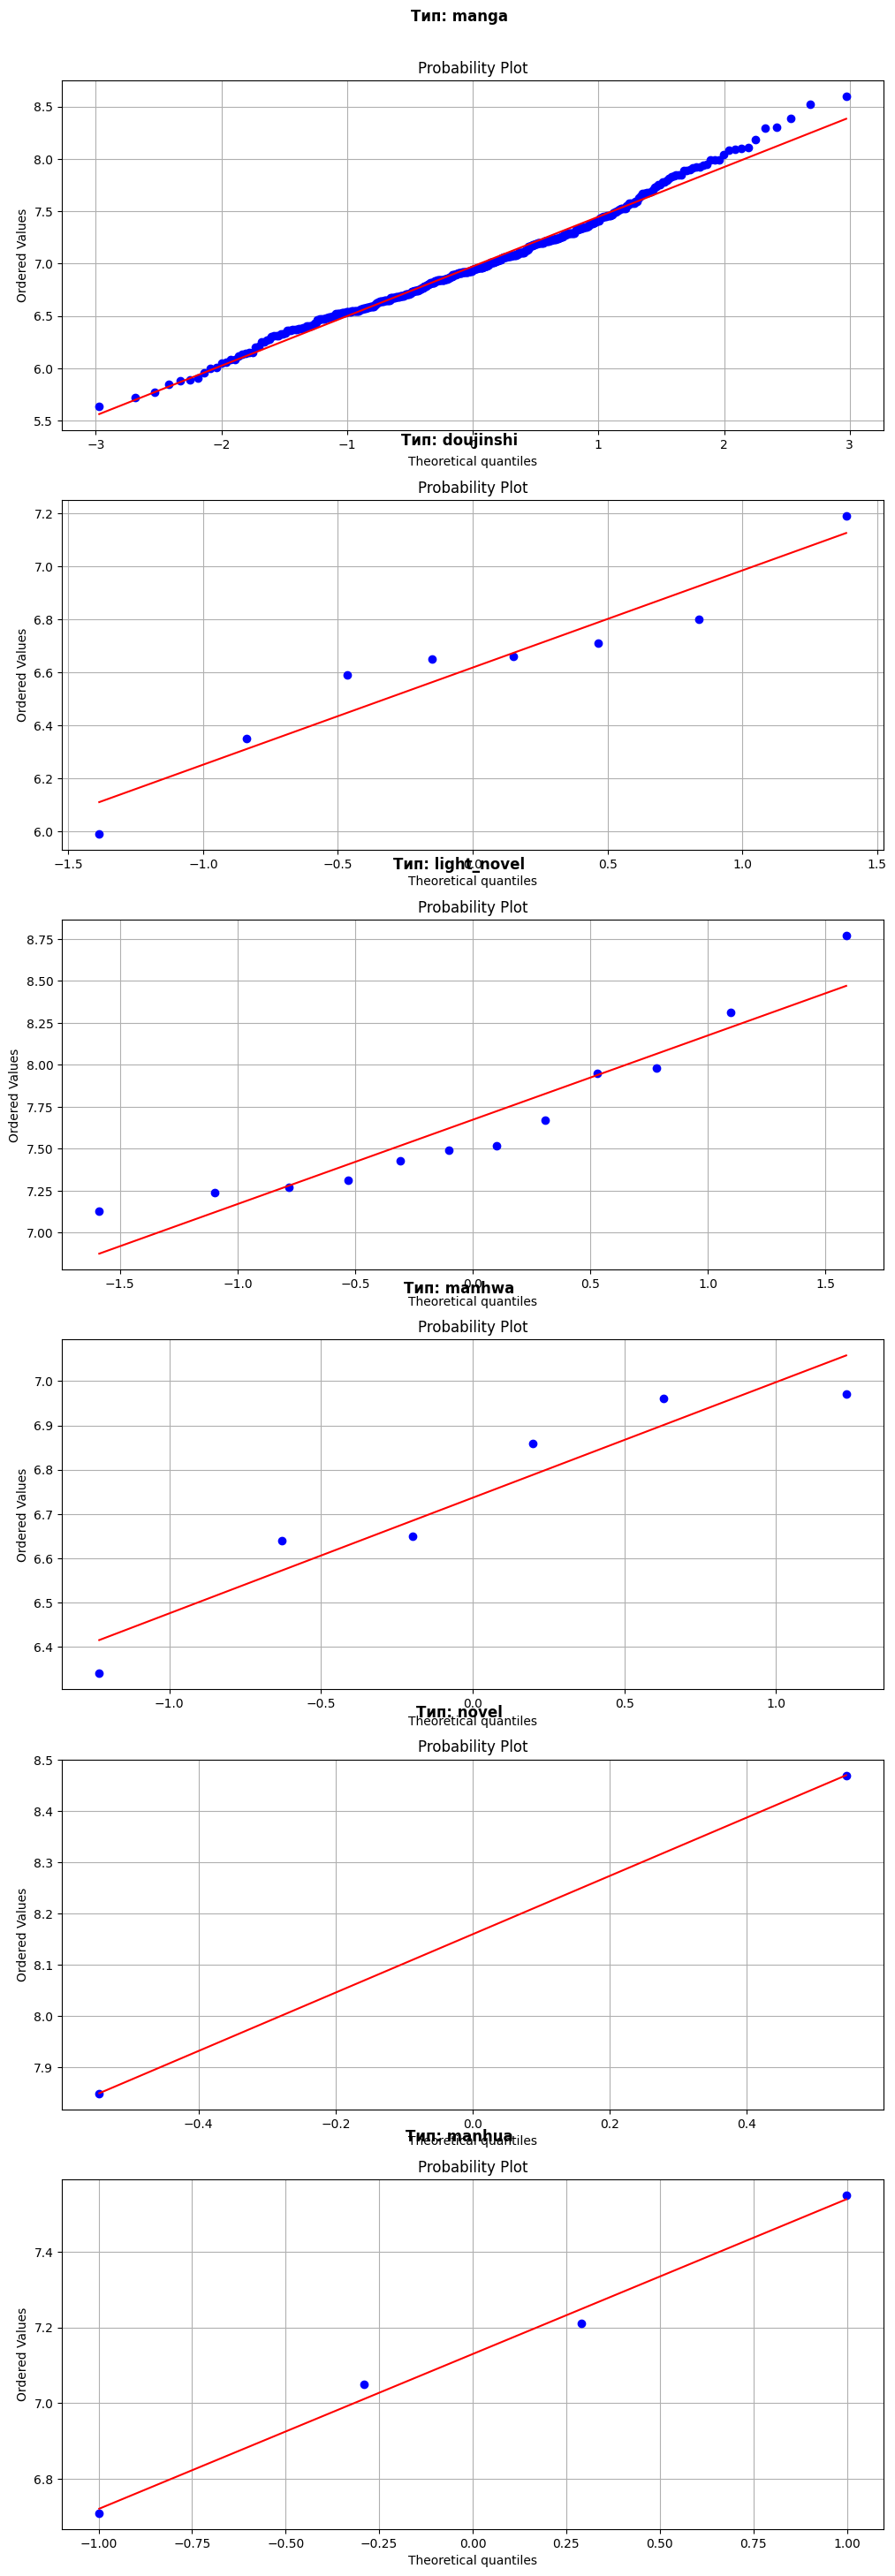

In [253]:
fig, axes = plt.subplots(len(data['type'].unique()), 1, figsize=(12, 6*len(top_genres)))
i = 0
for dtype in data['type'].unique():

    data_type = data[data[f'type'] == dtype]['score'].dropna()
    
    sts.probplot(data_type, plot=axes[i])  # Используем plot вместо ax
   

    fig.text(
        x=0.5,  # Центрируем по горизонтали
        y=0.9 - i*0.8/len(data['type'].unique()),  # Позиционируем по вертикали
        s=f'Тип: {dtype}',
        ha='center',
        va='center',
        fontsize=12,
        fontweight='bold'
    )
    
    # Подписи для подграфиков (опционально)
    axes[i].grid(True)
    i += 1
    

/home/baser/DATA/Project/2025/EconometricsAndStatistics/env/lib/python3.12/site-packages/scipy/stats/_stats_py.py:10730: RuntimeWarning: invalid value encountered in scalar divide
  slope = ssxym / ssxm
/home/baser/DATA/Project/2025/EconometricsAndStatistics/env/lib/python3.12/site-packages/scipy/stats/_stats_py.py:10744: RuntimeWarning: invalid value encountered in sqrt
  t = r * np.sqrt(df / ((1.0 - r + TINY)*(1.0 + r + TINY)))
/home/baser/DATA/Project/2025/EconometricsAndStatistics/env/lib/python3.12/site-packages/scipy/stats/_stats_py.py:10750: RuntimeWarning: invalid value encountered in scalar divide
  slope_stderr = np.sqrt((1 - r**2) * ssym / ssxm / df)


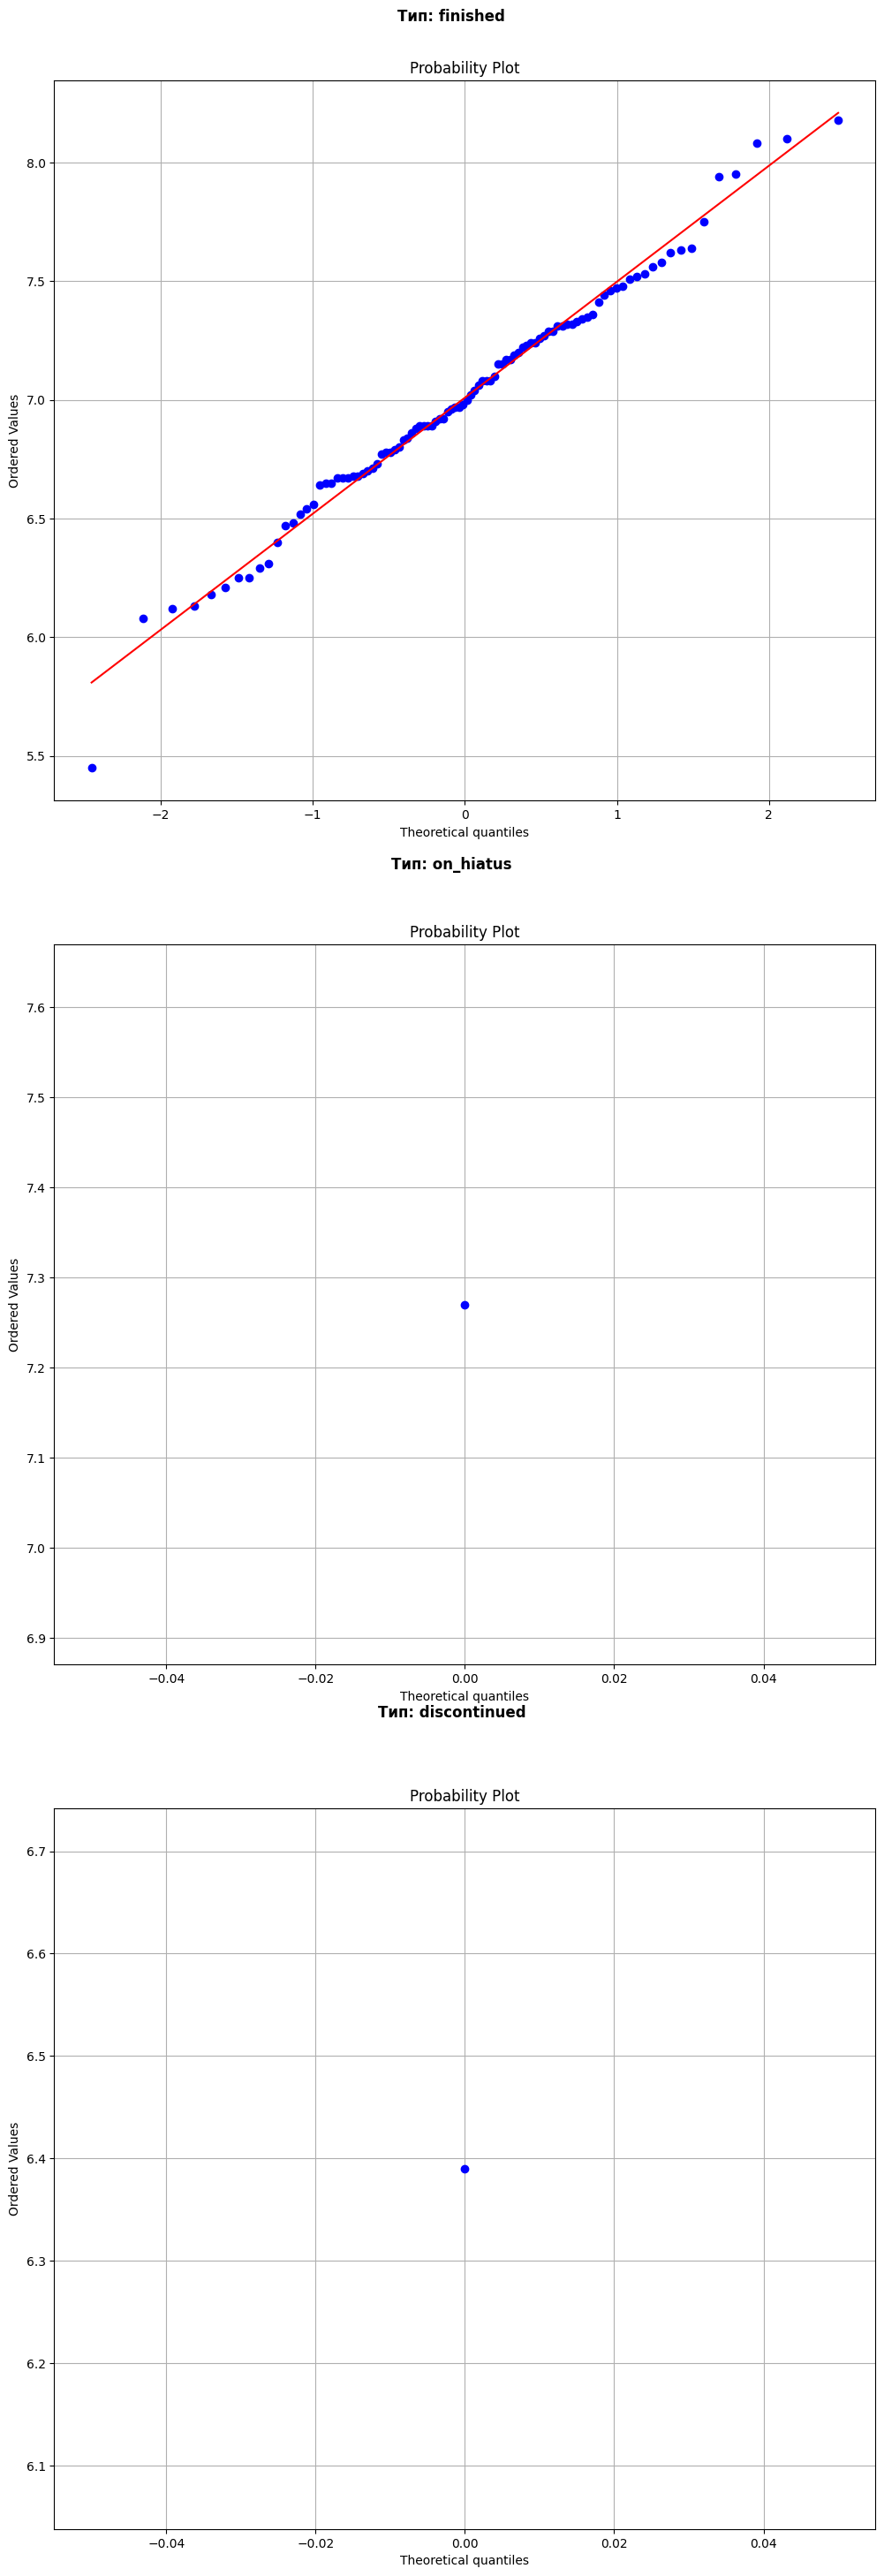

In [251]:
fig, axes = plt.subplots(len(data['status'].unique()), 1, figsize=(12, 6*len(top_genres)))
i = 0
for dstatus in data['status'].unique():

    data_status = data[data[f'status'] == dstatus]['score'].dropna()
    
    sts.probplot(data_status, plot=axes[i])  # Используем plot вместо ax
   

    fig.text(
        x=0.5,  # Центрируем по горизонтали
        y=0.9 - i*0.8/len(data['status'].unique()),  # Позиционируем по вертикали
        s=f'Тип: {dstatus}',
        ha='center',
        va='center',
        fontsize=12,
        fontweight='bold'
    )
    
    # Подписи для подграфиков (опционально)
    axes[i].grid(True)
    i += 1

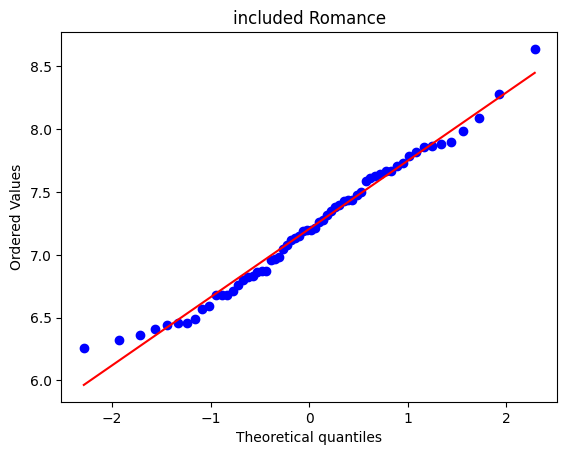

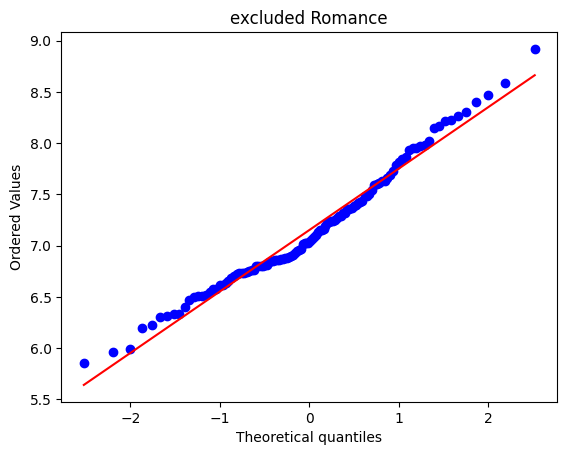

Romance
Levene: 0.5530057723677868
Normality included: 0.4337752430555125
Normality excluded: 0.04484562558968808
ttest p-value: 0.5434289218408865


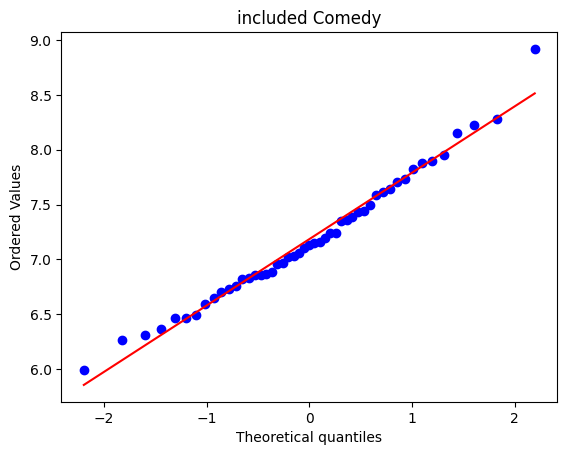

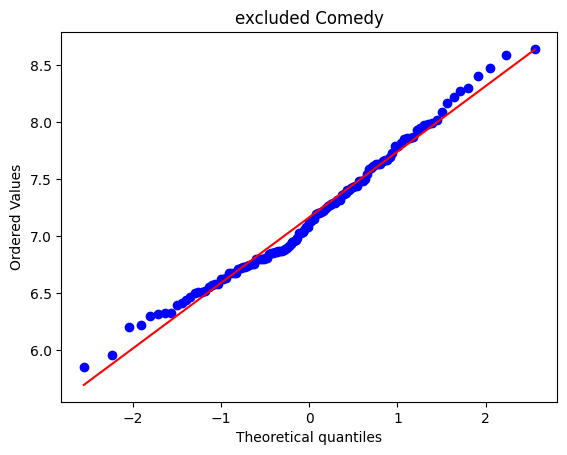

Comedy
Levene: 0.9927737966798096
Normality included: 0.6858666378073597
Normality excluded: 0.1106559812496124
ttest p-value: 0.8490551794982981


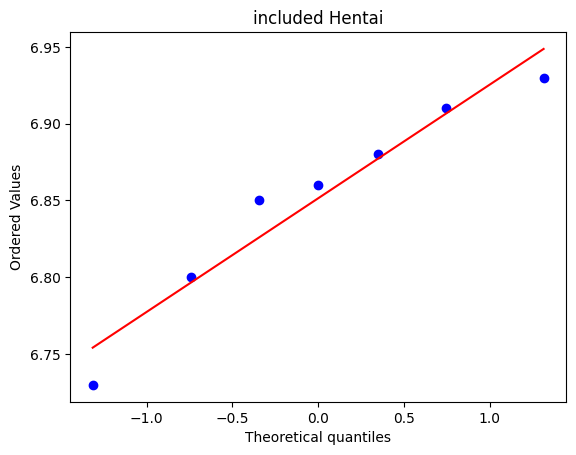

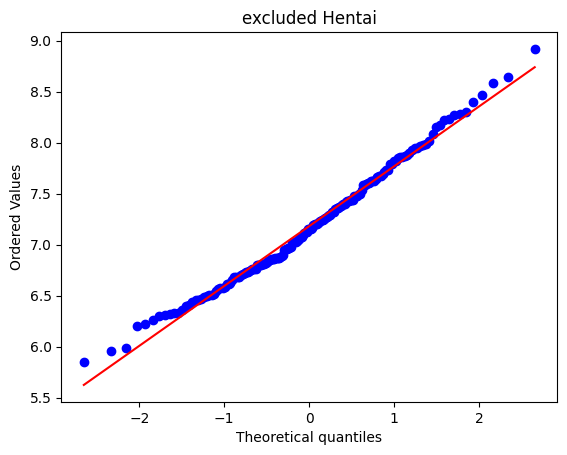

Hentai
Levene: 0.0012513867832116246
Normality included: 0.6686509925075551
Normality excluded: 0.17645839906462163
ttest p-value: 0.13591398517885533


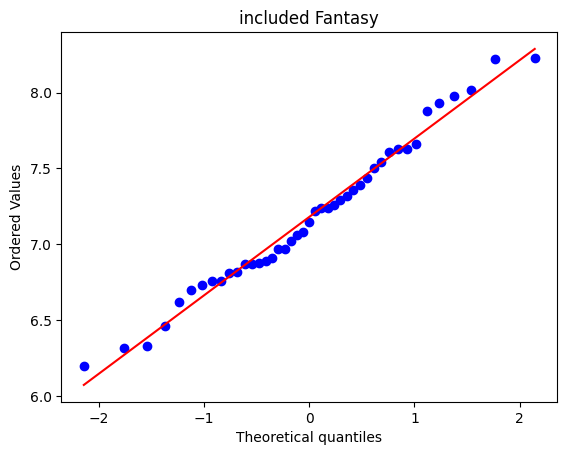

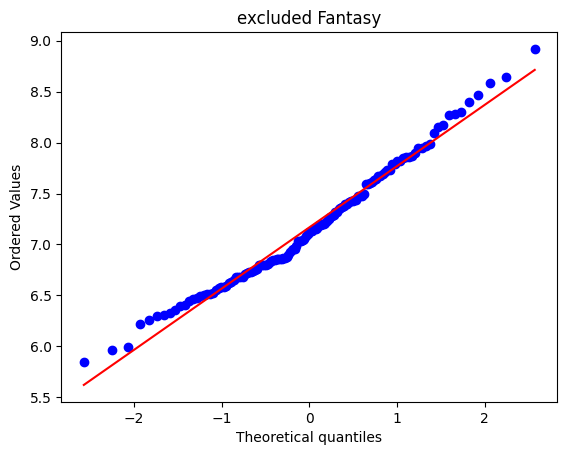

Fantasy
Levene: 0.20086558757745113
Normality included: 0.594896254583046
Normality excluded: 0.07542965676986546
ttest p-value: 0.8941384910387662


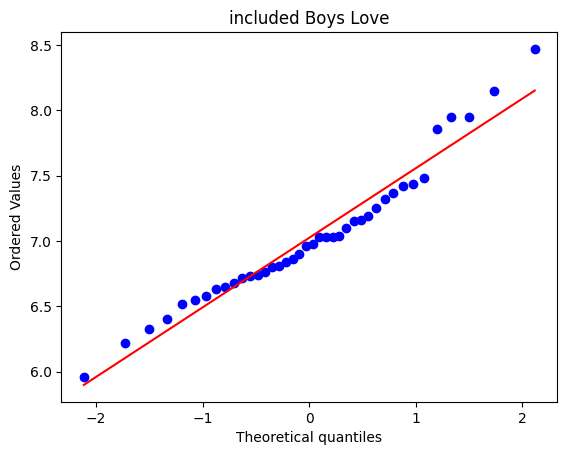

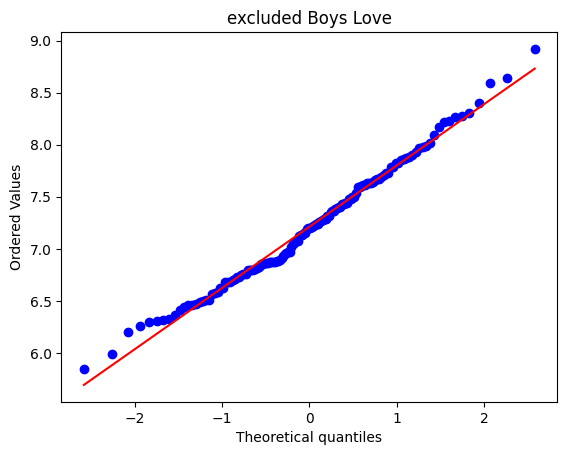

Boys Love
Levene: 0.17145666983199975
Normality included: 0.1480016461408335
Normality excluded: 0.3177830299145472
ttest p-value: 0.07090266057227575


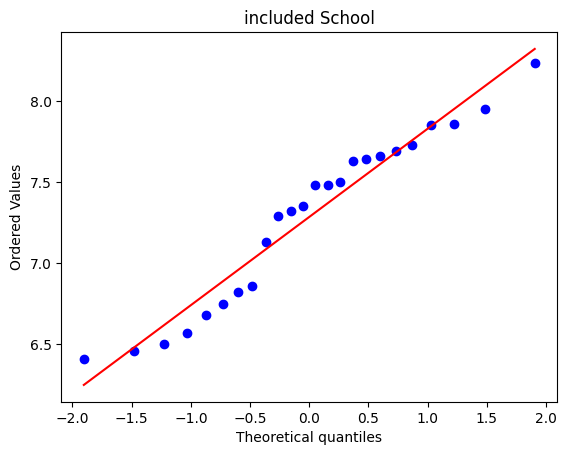

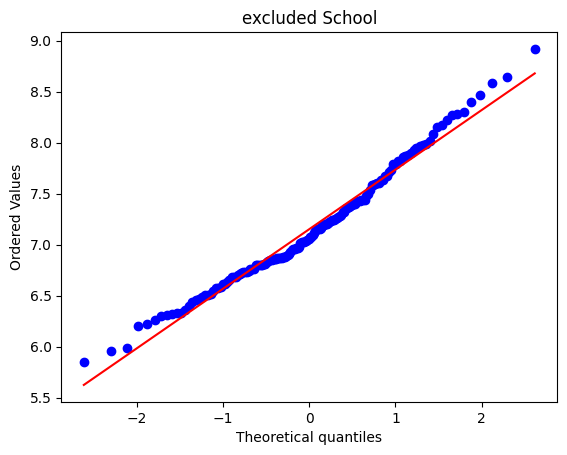

School
Levene: 0.7839283148367432
Normality included: 0.15598370910604353
Normality excluded: 0.024754808937829578
ttest p-value: 0.2972012361608824


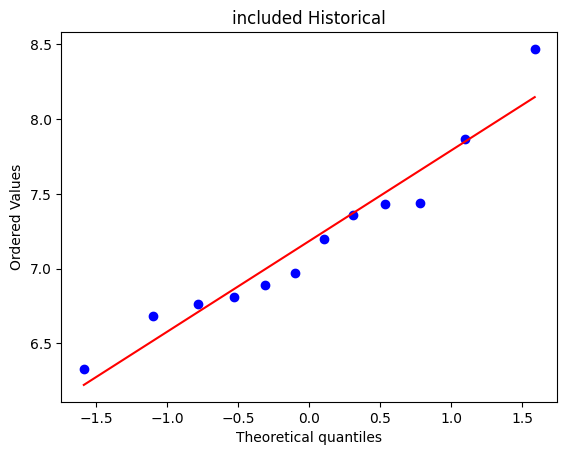

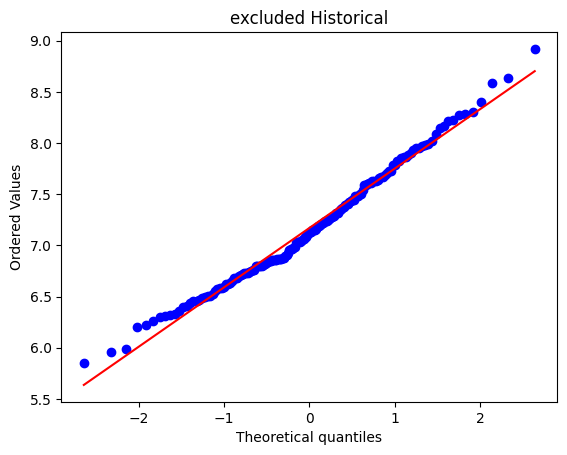

Historical
Levene: 0.8145969979690185
Normality included: 0.5869618117784605
Normality excluded: 0.10647329468917122
ttest p-value: 0.9322958224756894


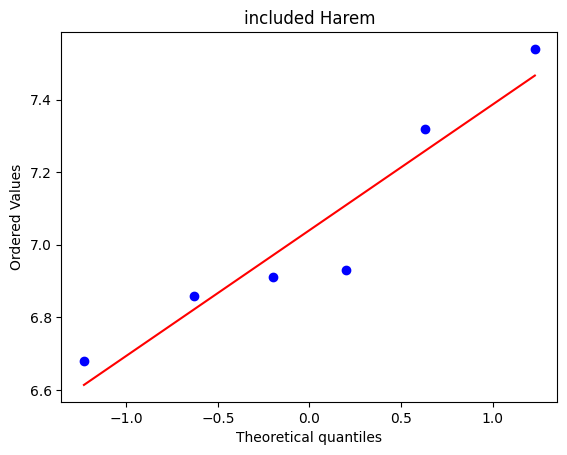

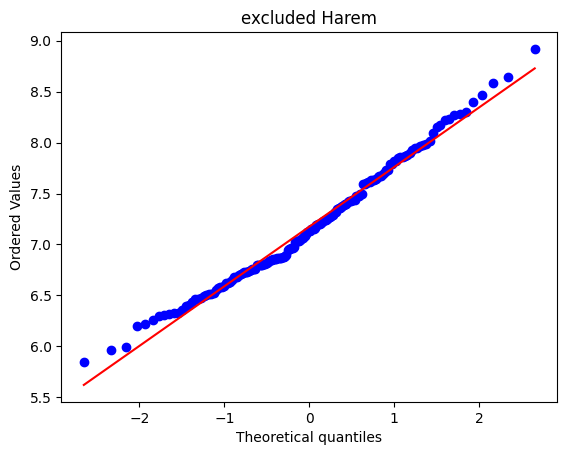

Harem
Levene: 0.08002897773880452
Normality included: 0.3760756532454437
Normality excluded: 0.08222100398737124
ttest p-value: 0.5745427298833538


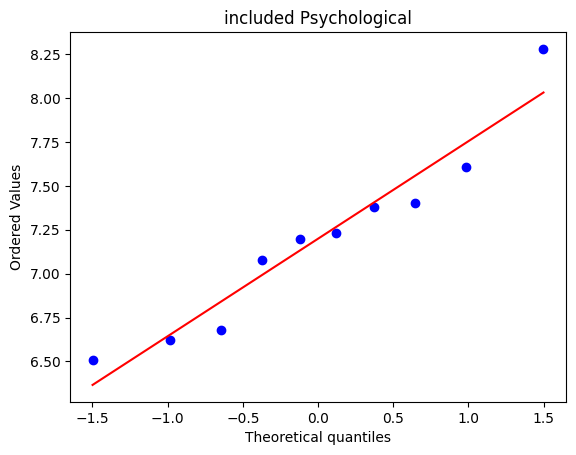

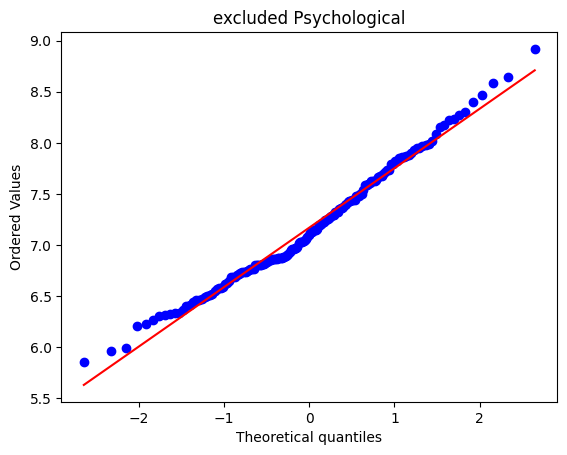

Psychological
Levene: 0.42370835707035714
Normality included: 0.5394109193298666
Normality excluded: 0.06430414888806198
ttest p-value: 0.8725339034366923


/tmp/ipykernel_550367/3908291078.py:6: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  b, ni = sts.shapiro(included)
/home/baser/DATA/Project/2025/EconometricsAndStatistics/env/lib/python3.12/site-packages/scipy/stats/_stats_py.py:10730: RuntimeWarning: invalid value encountered in scalar divide
  slope = ssxym / ssxm
/home/baser/DATA/Project/2025/EconometricsAndStatistics/env/lib/python3.12/site-packages/scipy/stats/_stats_py.py:10744: RuntimeWarning: invalid value encountered in sqrt
  t = r * np.sqrt(df / ((1.0 - r + TINY)*(1.0 + r + TINY)))
/home/baser/DATA/Project/2025/EconometricsAndStatistics/env/lib/python3.12/site-packages/scipy/stats/_stats_py.py:10750: RuntimeWarning: invalid value encountered in scalar divide
  slope_stderr = np.sqrt((1 - r**2) * ssym / ssxm / df)


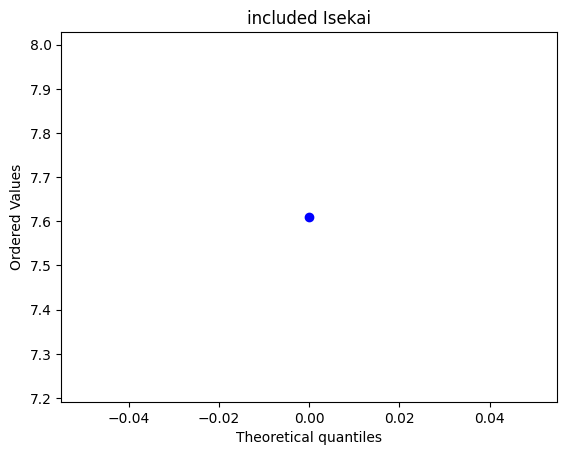

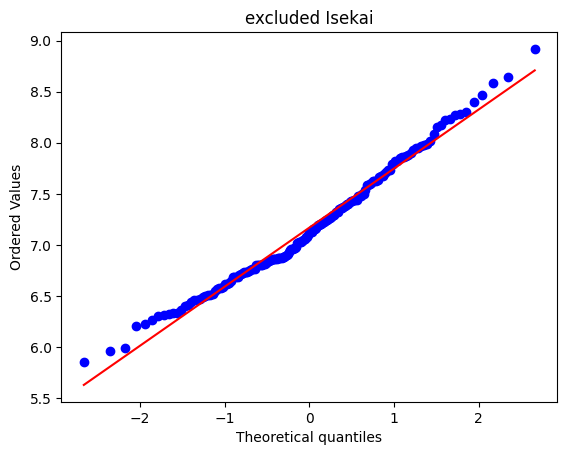

Isekai
Levene: 0.17550536007775142
Normality included: nan
Normality excluded: 0.04884420419726119
ttest p-value: 0.4462485165565717


In [13]:
def perform_ttest(included, excluded, title) :



    a, si = sts.levene(included, excluded)
    b, ni = sts.shapiro(included)
    c, ne = sts.shapiro(excluded)

    sts.probplot(included, plot=plt)
    plt.title('included ' + title)
    plt.figure()
    sts.probplot(excluded, plot=plt)
    plt.title('excluded ' + title)
    plt.show()

    d, tt = sts.ttest_ind(included, excluded)

    print(title, 'Levene: ' + str(si), "Normality included: " + str(ni), "Normality excluded: " + str(ne), 'ttest p-value: ' + str(tt), sep="\n")



for genre in top_genres :
    
    inc = data[data[f'has {genre}'] == 1]['score']
    exc = data[data[f'has {genre}'] == 0]['score']
    perform_ttest(inc, exc, genre)

for theme in top_themes :
    inc = data[data[f'has {theme}'] == 1]['score']
    exc = data[data[f'has {theme}'] == 0]['score']
    perform_ttest(inc, exc, theme)
